# 02. The classical baseline: dynamic harmonic regression with ARIMA errors

A Bayesian model is only worth building if it can stand up to a strong
classical one, so the comparison needs a serious opponent. That opponent is
dynamic harmonic regression with ARIMA errors. The shared design matrix
(local-clock seasonal basis, temperature, dew point, irradiance, degree days,
demand lags, holiday) enters a SARIMAX regression, and a low-order
autoregression mops up whatever structure the regression leaves in the
residuals. A bare ARIMA on raw half-hourly demand would be the strawman, so I
do not use it.

The fitted state-space model gives an analytic Gaussian predictive. That is
handy twice over: the probabilistic scores here come out in closed form, and
those same closed forms are the correctness reference for the sample-based
estimators that score the BSTS later. All the heavy fitting ran in
`scripts/fit_arima.py`, so this notebook just reads its artifacts.

### Model structure

Demand is a regression mean plus a stationary AR error. Order selection
(below) settles on a first-order error, so the lag-1 coefficient `phi` and the
innovation scale `sigma` are the only error parameters.

```mermaid
flowchart TD
  x[x_t regression design: harmonics, weather, degree days, lags, holiday] --> mu[mu_t regression mean = x_t' beta]
  beta[beta regression coefficients] --> mu
  phi[phi AR1 coefficient] --> eta[eta_t AR1 error]
  sigma[sigma innovation scale] --> eta
  mu --> y[y_t demand]
  eta --> y
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from nemforecastdemand.config import load_config
from nemforecastdemand.data.loaders import load_panel, load_splits
from nemforecastdemand.evaluation.calibration import pit_gaussian, pit_histogram
from nemforecastdemand.evaluation.metrics import (
    crps_gaussian,
    interval_coverage,
    log_score_gaussian,
    mase,
    pinball_loss,
)
from nemforecastdemand.plotting import (
    MODEL_COLOURS,
    fan_chart,
    horizon_curve,
    palette,
    save_figure,
    setup_style,
)
from nemforecastdemand.splits import rolling_origins
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()
panel = load_panel(cfg.paths.processed)
splits = load_splits(cfg.paths.processed)
arrays, meta = load_artifact(cfg.paths.artifacts / "arima")

test_origins = rolling_origins(
    splits["test"].index, panel.index, cfg.origins, cfg.horizon, max(cfg.features.demand_lags)
)
assert len(test_origins) == arrays["forecast_mean"].shape[0]

## Order selection and the seasonal basis

I fit each candidate residual order on the training split and score it by mean
CRPS over every validation origin (two a day, at 00:00 and 12:00 AEST) under
the archived weather forecasts. Choosing on out-of-sample CRPS is the honest
way to do it: the question is which order forecasts best, not which one fits
the training data best, and those need not be the same order. The final model
refits the chosen order on the full history up to the test boundary.

In [2]:
selection = pd.DataFrame(meta["selection"])
selection["order"] = selection["order"].apply(tuple)
selection[["order", "val_crps_mw", "fit_seconds"]].set_index("order").round(2)

,val_crps_mw,fit_seconds
order,,
"(1, 0, 0)",344.12,259.94
"(2, 0, 0)",360.71,295.74


*Takeaway: a first-order autoregression wins on validation CRPS, so AR(1) is the classical baseline.*

At the chosen order, the seasonal-basis comparison confirms notebook 01:
trigonometric harmonics and periodic RBFs are statistically indistinguishable,
so the harmonics stay.

In [3]:
pd.DataFrame(
    {
        "validation CRPS (MW)": meta["basis_scores_mw"],
        "chosen": {b: b == meta["chosen_basis"] for b in meta["basis_scores_mw"]},
    }
).round(1)

,validation CRPS (MW),chosen
fourier,344.1,True
rbf,344.5,False


*Takeaway: the two bases tie on validation CRPS, so the trigonometric basis stays the default.*

## Validation calibration

Before this model goes near the test set, I check whether its Gaussian
predictive is honest about its own uncertainty. The tool is the probability
integral transform (PIT): feed each observation through its own predictive and,
if the model is calibrated, the results come out uniform. A flat histogram
means calibration, a central hump means the bands are too wide, and a U-shape
means they are too narrow.

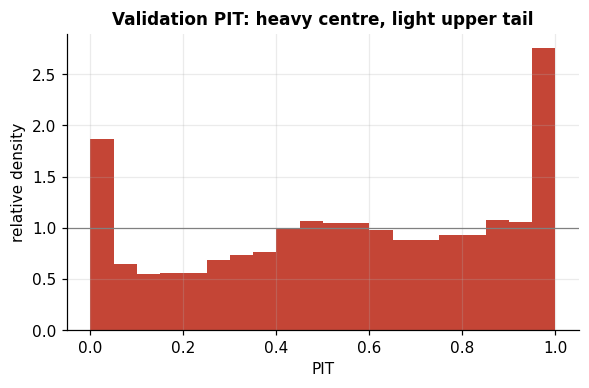

In [4]:
pit = pit_gaussian(arrays["y_val"].ravel(), arrays["val_mean"].ravel(), arrays["val_sd"].ravel())
density, edges = pit_histogram(pit, bins=20)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(edges[:-1], density, width=np.diff(edges), align="edge", color=MODEL_COLOURS["ARIMA"])
ax.axhline(1.0, color="grey", lw=0.8)
ax.set_xlabel("PIT")
ax.set_ylabel("relative density")
ax.set_title("Validation PIT: heavy centre, light upper tail")
plt.show()

*Takeaway: the central hump and light tail show a single Gaussian variance running slightly wide in the calm hours and narrow in the peaks, the opening a heteroskedastic scale will exploit.*

## Test-set performance under each weather-input variant

The headline row feeds the model the ECMWF forecast exactly as it was issued
one day ahead. Perfect foresight, using the ERA5 actuals, bounds how much of
the remaining error is down to the weather forecast at all. The perturbation
rows sit in between, degrading the actuals with calibrated correlated noise at
multiples of the measured forecast error. The seasonal naive anchors the
table, and its training MAE doubles as the scaling base for MASE.

In [5]:
quantiles = np.array(cfg.evaluation.quantiles)
z_quantiles = stats.norm.ppf(quantiles)


def score_variant(mean: np.ndarray, sd: np.ndarray) -> dict[str, float]:
    y = arrays["y_test"]
    crps = crps_gaussian(y, mean, sd)
    quantile_paths = mean[None] + z_quantiles[:, None, None] * sd[None]
    row = {
        "CRPS (MW)": crps.mean(),
        "log score": log_score_gaussian(y, mean, sd).mean(),
        "pinball (MW)": pinball_loss(
            y.ravel(), quantile_paths.reshape(len(quantiles), -1), quantiles
        ).mean(),
        "MAE (MW)": np.abs(y - mean).mean(),
        "MASE": mase(y.ravel(), mean.ravel(), meta["naive_train_mae_mw"]),
    }
    for level in cfg.evaluation.interval_levels:
        z = stats.norm.ppf(0.5 + level / 2)
        row[f"cover {level:.0%}"] = interval_coverage(
            y.ravel(), (mean - z * sd).ravel(), (mean + z * sd).ravel()
        )
    return row


variant_names = ["forecast", "actual"] + [
    f"perturb_{m:g}" for m in cfg.perturbation.sweep_multipliers if m > 0
]
rows = {name: score_variant(arrays[f"{name}_mean"], arrays[f"{name}_sd"]) for name in variant_names}
rows["seasonal naive"] = score_variant(arrays["naive_mean"], arrays["naive_sd"])
scores = pd.DataFrame(rows).T
scores.round(3)

,CRPS (MW),log score,pinball (MW),MAE (MW),MASE,cover 50%,cover 80%,cover 95%
forecast,257.979,7.621,107.221,345.506,0.534,0.540,0.785,0.914
actual,255.965,7.590,106.056,344.371,0.532,0.539,0.780,0.918
perturb_0.5,256.882,7.593,106.443,345.891,0.534,0.538,0.781,0.917
perturb_1,257.892,7.596,106.844,346.939,0.536,0.536,0.781,0.915
perturb_1.5,259.914,7.626,108.048,348.869,0.539,0.539,0.781,0.911
perturb_2,262.390,7.602,108.355,354.492,0.547,0.529,0.767,0.914
seasonal naive,489.587,8.037,200.700,673.011,1.039,0.560,0.817,0.945


*Takeaway: the baseline beats the seasonal naive by over 200 MW of CRPS (258 against 490), and perfect-foresight weather buys almost nothing over the archived forecast (258 against 256).*

A day ahead, ECMWF weather error is a tiny part of the demand-forecast error
budget. The calibration is the weak point: one Gaussian variance cannot be
honest at every hour. It runs wide at the centre, where the 50% interval
catches 54% of outcomes, and narrow further out, where the 80% and 95%
intervals catch 79% and 91%. That mismatch is what the heteroskedastic BSTS
exploits.

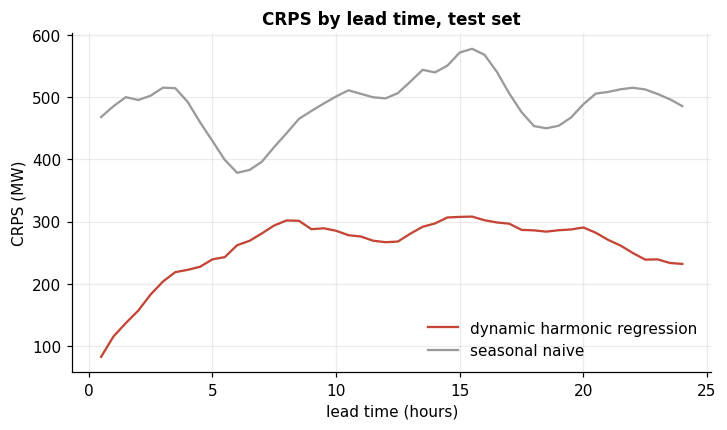

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4))
crps_headline = crps_gaussian(arrays["y_test"], arrays["forecast_mean"], arrays["forecast_sd"])
crps_naive = crps_gaussian(arrays["y_test"], arrays["naive_mean"], arrays["naive_sd"])
horizon_curve(ax, crps_headline, "dynamic harmonic regression", MODEL_COLOURS["ARIMA"])
horizon_curve(ax, crps_naive, "seasonal naive", MODEL_COLOURS["seasonal naive"])
ax.set_ylabel("CRPS (MW)")
ax.set_title("CRPS by lead time, test set")
ax.legend()
save_figure(fig, "arima_horizon_crps", cfg.paths.figures)
plt.show()

*Takeaway: error grows with lead as the AR error decays back to the regression, then eases late where the overnight trough is intrinsically easy to call.*

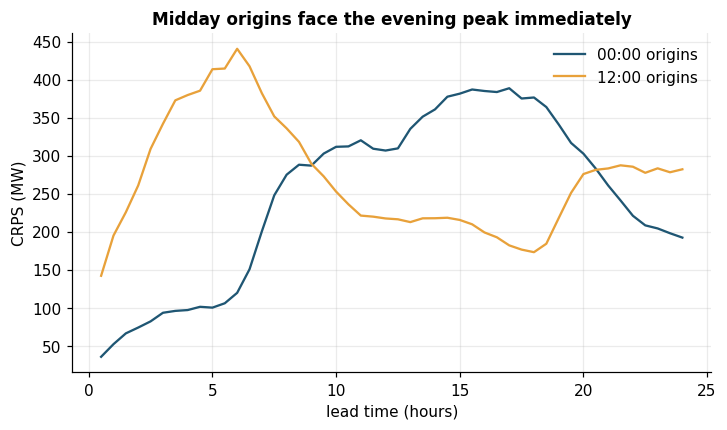

In [7]:
market_hour = test_origins.tz_convert("Australia/Brisbane").hour
fig, ax = plt.subplots(figsize=(7.5, 4))
for hour, colour in ((0, palette("demand")), (12, palette("irradiance"))):
    horizon_curve(ax, crps_headline[market_hour == hour], f"{hour:02d}:00 origins", colour)
ax.set_ylabel("CRPS (MW)")
ax.set_title("Midday origins face the evening peak immediately")
ax.legend()
plt.show()

*Takeaway: midday origins hit the hard evening peak in their first hours, so the two daily origins trace different error curves.*

## What a forecast looks like

A typical day and the worst day of the test set, each with its central 50, 80
and 95% bands. The worst day is where the variance story bites hardest, so I
keep it for the cross-model case study in notebook 05.

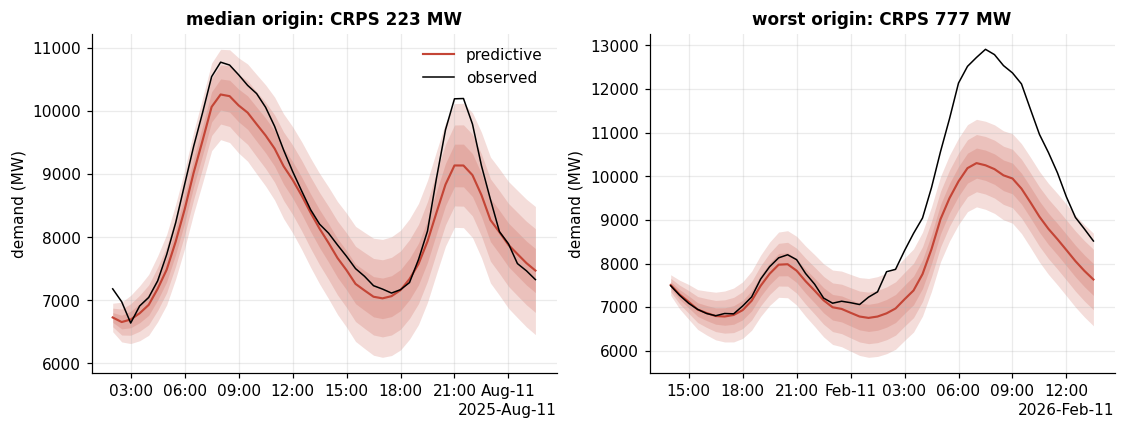

In [8]:
daily_crps = crps_headline.mean(axis=1)
typical = int(np.argsort(daily_crps)[len(daily_crps) // 2])
worst = int(daily_crps.argmax())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, origin_pos, title in (
    (axes[0], typical, "median origin"),
    (axes[1], worst, "worst origin"),
):
    origin = test_origins[origin_pos]
    index = pd.date_range(origin, periods=cfg.horizon, freq="30min")
    fan_chart(
        ax,
        index,
        mean=arrays["forecast_mean"][origin_pos],
        sd=arrays["forecast_sd"][origin_pos],
        colour=MODEL_COLOURS["ARIMA"],
        label="predictive",
    )
    ax.plot(
        index.tz_convert("Australia/Brisbane"),
        arrays["y_test"][origin_pos],
        color="black",
        lw=1.0,
        label="observed",
    )
    ax.set_title(f"{title}: CRPS {daily_crps[origin_pos]:.0f} MW")
    ax.set_ylabel("demand (MW)")
axes[0].legend()
save_figure(fig, "arima_fan_charts", cfg.paths.figures)
plt.show()

*Takeaway: the median day sits comfortably inside the bands; the worst day is an under-forecast peak that the constant-width band cannot widen to meet.*

## Cost

Fit and forecast wall-clock, as recorded by the fitting script. The BSTS
notebooks put these in context; the headline is simple: this baseline is the
cheapest serious model in the comparison.

In [9]:
pd.Series(
    {
        "final fit (s)": meta["timings_seconds"]["final_fit"],
        "forecast per origin (s)": meta["forecast_seconds_per_origin"],
        "exogenous columns": meta["n_exog"],
        "chosen order": str(tuple(meta["chosen_order"])),
    }
).to_frame("value")

,value
final fit (s),260.880449
forecast per origin (s),0.204632
exogenous columns,58
chosen order,"(1, 0, 0)"


*Takeaway: fit and forecast are both cheap, so ARIMA sets the cost floor the richer models are measured against.*

## Summary

- Order selection on validation CRPS settles on a first-order autoregression.
  A second-order one fits the training data more closely but forecasts a little
  worse out of sample, so AR(1) is the honest classical choice. The BSTS in
  notebooks 03 to 05 uses an AR([1,2]) error instead, where the lag-2 term
  earns its keep on short-lead sharpness.
- The trigonometric and RBF seasonal bases tie, confirming notebook 01, so the
  harmonics stay the project default.
- The baseline beats the seasonal naive decisively (258 against 490 MW CRPS)
  and barely moves when perfect-foresight weather is swapped for the real
  archived forecast.
- A single Gaussian variance has to average over the easy small hours and the
  hard evening peaks alike, so it cannot be honest at both ends at once. A
  covariate-driven variance is the opening the heteroskedastic BSTS exploits.